# Case Study 2: Handling Data Skew in Large Spark Joins 

## Problem

On the case 1, the dimension table was small enough to be broadcasted.

However, in real-world workloads, both tables can be too large for Broadcast Join.

In this case, Spark usually falls back to Sort Merge Join, which requires shuffling both datasets.

When the join key is skewed, some partitions receive much more data than others, causing slow tasks, spills, and inefficient execution.

## Objective

The objective is to understand how to optimize a large-to-large join when Broadcast Join is not possible.

We will compare:

1. Standard Sort Merge Join
2. Sort Merge Join with AQE Skew Join Optimization
3. Manual salting technique

## Expected Learning

By the end, we should understand:

- Why Broadcast Join is not always possible
- How skew affects shuffle partitions
- How AQE handles skewed partitions
- When manual salting is useful
- How to compare Spark UI metrics before and after optimization

---

In [1]:
from init_spark import spark_session
from pyspark.sql.functions import *
from pyspark.sql import functions as F
from functools import reduce

In [2]:
spark = spark_session()

Spark UI: http://localhost:4040


# Read DataFrames

In [3]:
spark.sparkContext.setJobDescription('Distribution_Fact_OrderLines')

fact_orders_lines = spark.read.format("delta").load(r"C:\Users\tfcosta\Lab\Bronze\fact_order_lines")

In [4]:
spark.sparkContext.setJobDescription('Distribution_Fact_Orders')

fact_orders = spark.read.format("delta").load(r"C:\Users\tfcosta\Lab\Bronze\fact_orders")

# See the partitions of each delta

In [5]:
spark.sparkContext.setJobDescription('fact_orders_lines_partitions')

fact_orders_lines.rdd.getNumPartitions()

6

In [6]:
spark.sparkContext.setJobDescription('fact_orders_partitions')

fact_orders.rdd.getNumPartitions()

4

# Distribution of dataset to detection if will have or not data skew

In [7]:
def profile_key_distribution(df : DataFrame, key : str) -> DataFrame:
    '''
    This function profiles the distribution of a key in a DataFrame by calculating the count of rows for each 
    key value and then computing various statistics on these counts, 
    including the number of distinct keys, average count, percentiles (25th, 50th, 75th, 90th, 99th), and the maximum count.

     Parameters:
      df (DataFrame): The input DataFrame to be profiled.
    key (str): The column name of the key to be profiled.
     
     Returns:
      DataFrame: A DataFrame containing the distribution statistics of the key.
    '''
    counts = (
        df.groupBy(key)
          .count()
    )

    return (
        counts.agg(
            count("*").alias("distinct_keys"),
            avg("count").alias("avg"),
            expr("percentile_approx(count, 0.25)").alias("p25"),
            expr("percentile_approx(count, 0.50)").alias("p50"),
            expr("percentile_approx(count, 0.75)").alias("p75"),
            expr("percentile_approx(count, 0.90)").alias("p90"),
            expr("percentile_approx(count, 0.99)").alias("p99"),
            max("count").alias("max")
        )
    )

fact_orders_lines_profile = profile_key_distribution(fact_orders_lines, "order_id")
fact_orders_profile = profile_key_distribution(fact_orders, "order_id")

spark.sparkContext.setJobDescription('fact_orders_lines_profile')
fact_orders_lines_profile.show()

spark.sparkContext.setJobDescription('fact_orders_profile')
fact_orders_profile.show()


"""
This output shows a severe data skew on the 'order_id' join key.

- 25% of the order_id values have 1 row.
- 50% of the order_id values have 1 row.
- 75% of the order_id values have 1 row.
- 90% of the order_id values have 2 or fewer rows.
- 99% of the order_id values have 3 or fewer rows.

However, the largest order_id contains 10,000,001 rows.

This indicates an extremely skewed key distribution, where almost all keys contain only a few dozen rows, 
while one key contains millions of rows and this will cause long-running tasks, and memory/disk spills during joins or aggregations.
"""

+-------------+-----------------+---+---+---+---+---+--------+
|distinct_keys|              avg|p25|p50|p75|p90|p99|     max|
+-------------+-----------------+---+---+---+---+---+--------+
|      2360535|16.09804557017795|  1|  1|  1|  2|  3|10000001|
+-------------+-----------------+---+---+---+---+---+--------+

+-------------+---+---+---+---+---+---+---+
|distinct_keys|avg|p25|p50|p75|p90|p99|max|
+-------------+---+---+---+---+---+---+---+
|      6000000|1.0|  1|  1|  1|  1|  1|  1|
+-------------+---+---+---+---+---+---+---+



"\nThis output shows a severe data skew on the 'order_id' join key.\n\n- 25% of the order_id values have 1 row.\n- 50% of the order_id values have 1 row.\n- 75% of the order_id values have 1 row.\n- 90% of the order_id values have 2 or fewer rows.\n- 99% of the order_id values have 3 or fewer rows.\n\nHowever, the largest order_id contains 10,000,001 rows.\n\nThis indicates an extremely skewed key distribution, where almost all keys contain only a few dozen rows, \nwhile one key contains millions of rows and this will cause long-running tasks, and memory/disk spills during joins or aggregations.\n"

In [8]:
spark.sparkContext.setJobDescription('Distribution_Fact_OrderLines')

fact_orders_lines \
    .groupBy("order_id") \
    .count() \
    .orderBy(F.desc("count")) \
    .show(10, False)

+--------+--------+
|order_id|count   |
+--------+--------+
|1       |10000001|
|2       |8000001 |
|3       |7000000 |
|4       |6000000 |
|5       |4000000 |
|5046944 |7       |
|1695730 |7       |
|1955851 |7       |
|3515241 |7       |
|5326715 |7       |
+--------+--------+
only showing top 10 rows



In [9]:
spark.sparkContext.setJobDescription('Distribution_Fact_Orders')

fact_orders \
    .groupBy("order_id") \
    .count() \
    .orderBy(F.desc("count")) \
    .show(10, False)

+--------+-----+
|order_id|count|
+--------+-----+
|672     |1    |
|1500135 |1    |
|1500295 |1    |
|1500322 |1    |
|27      |1    |
|1500333 |1    |
|1500370 |1    |
|1500334 |1    |
|904     |1    |
|1500337 |1    |
+--------+-----+
only showing top 10 rows



### Cenario 1 - Configs disable (AQE + Skew Join + Coalesce Partitions) and without Salting 

For better understanding, we will disable several Spark optimizations, including:

- Adaptive Query Execution (AQE)
- Broadcast Join
- Coalesce Partitions
- Skew Join Optimization

If these settings are enabled, Spark will automatically try to determine the most efficient execution plan for the join. However, our goal is to understand what happens behind the scenes during a Spark job execution, so we will disable these optimizations and analyze the behavior manually.


In [ ]:
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)
spark.conf.set("spark.sql.adaptive.enabled", False)
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", False )
spark.conf.set("spark.sql.adaptive.skewJoin.enabled", False)

In [ ]:
import time

start_time = time.time()

spark.sparkContext.setJobDescription('Join_Deltas_Orders_OrderLines')

Df_Joined = fact_orders_lines.join(fact_orders, on="order_id", how="inner")

Df_Joined.write.format("noop").mode("overwrite").save() # Trigger the execution of the join without writing to storage

end_time = time.time()
print(f"Time of execution: {end_time - start_time} seconds")

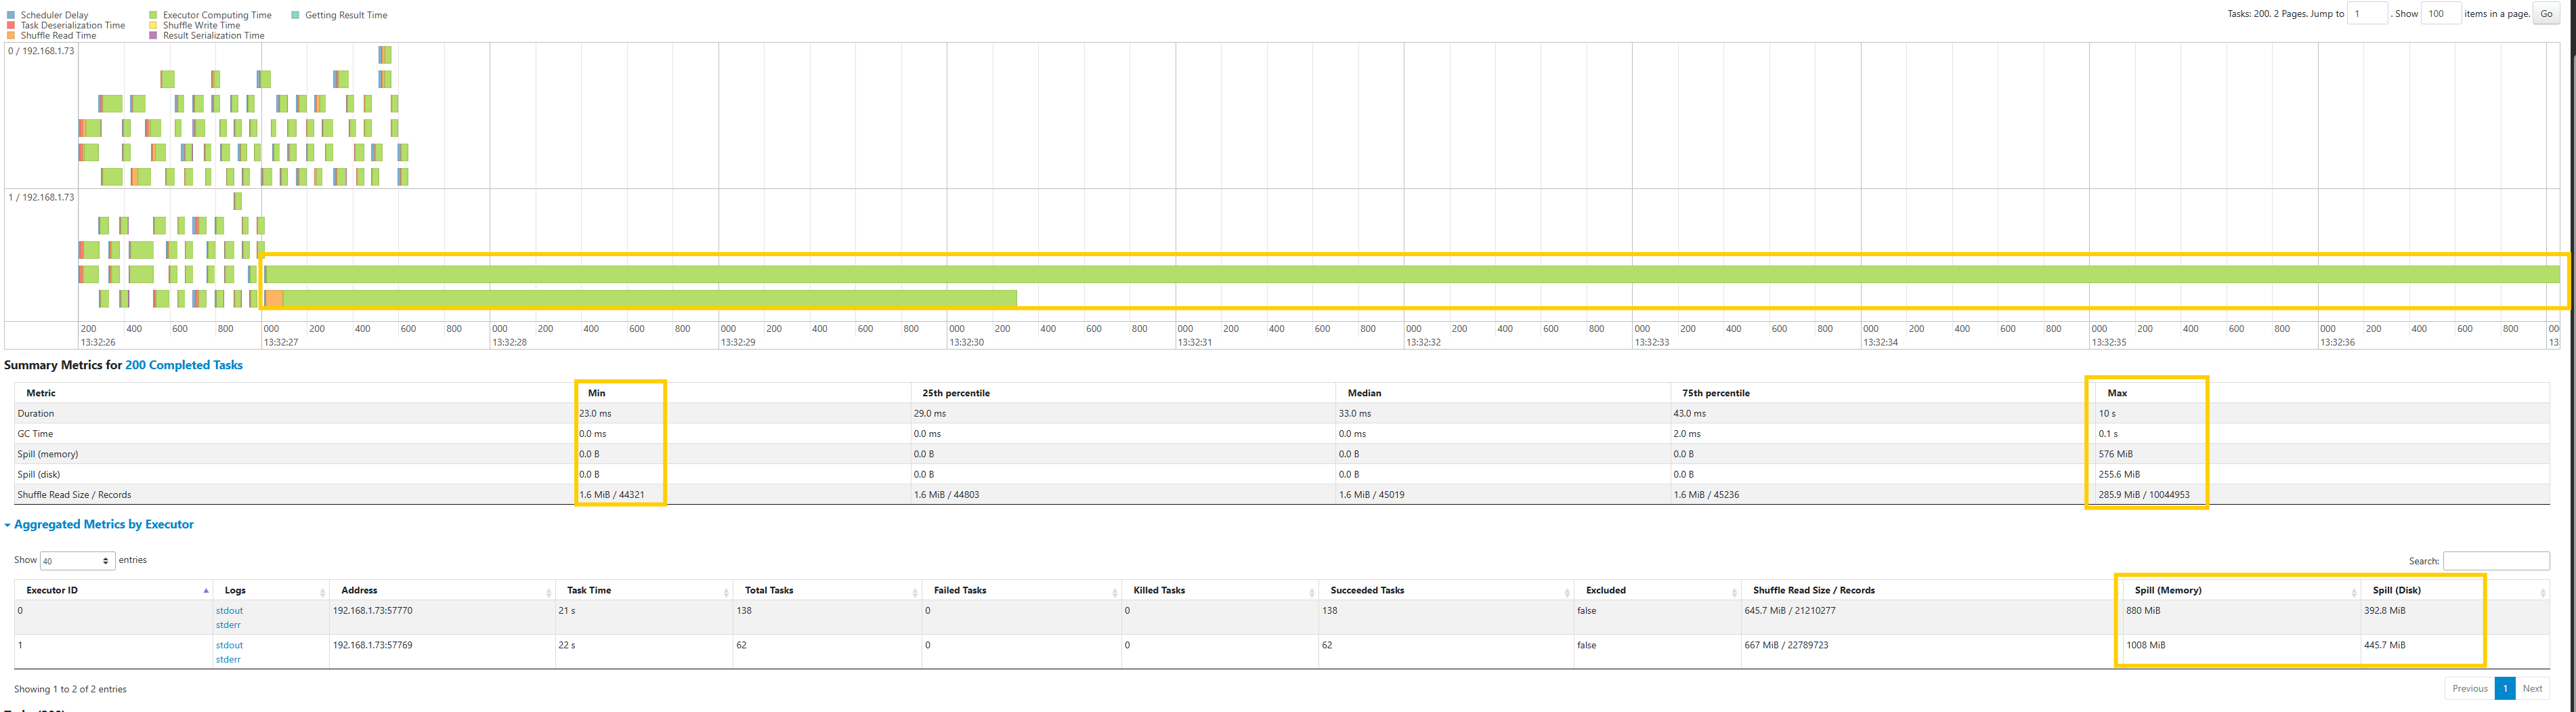

## Execution Analysis (AQE Disabled, No Salting)

This execution represents the baseline scenario where all adaptive Spark optimizations were disabled:

- Adaptive Query Execution (AQE) = Disabled
- Skew Join Optimization = Disabled
- Coalesce Partitions = Disabled
- Salting = Not Applied

The objective of this execution is to observe the raw impact of extreme key skew on a shuffle-based join

---

### Key Observations

#### Severe Task Imbalance

The Spark UI clearly shows a highly uneven workload distribution

| Metric | Value |
|----------|----------|
| Min Duration | 23 ms |
| Median Duration | 33 ms |
| 75th Percentile | 43 ms |
| Max Duration | 10 s |

While most tasks completed in a few milliseconds, the slowest task required approximately **10 seconds**, indicating that one or more partitions received significantly more data than the rest

This indicates a symptom of data skew

---

#### Large Variance in Shuffle Read

The shuffle distribution is uneven

| Metric | Value |
|----------|----------|
| Min Shuffle Read | 1.6 MiB |
| Median Shuffle Read | 1.6 MiB |
| Max Shuffle Read | 285.9 MiB |

Most partitions processed only a few megabytes of data, while the largest partition processed almost **286 MiB**.

This confirms that a small number of join keys concentrated a disproportionate amount of data into a few shuffle partitions

---

#### Significant Memory Pressure

The workload generated substantial spill activity

Per task:

| Metric | Max |
|----------|----------|
| Spill (Memory) | 576 MiB |
| Spill (Disk) | 255.6 MiB |

Aggregated by executor:

| Executor | Memory Spill | Disk Spill |
|----------|----------|----------|
| Executor 0 | 880 MiB | 392.8 MiB |
| Executor 1 | 1026 MiB | 445.7 MiB |

The amount of spill indicates that some partitions became too large to be processed entirely in memory on the executores, forcing Spark to write intermediate data to disk
This requires spark to write and re-read data multiple times from the intermediate area

---

#### Uneven Parallelism

Spark created 200 tasks, the execution timeline shows that most tasks completed very quickly while a small number of tasks dominated the overall execution time 
but some tasks remained idle while waiting for a few large skewed tasks to finish processing


---

### What This Means

The execution metrics reveal the direct impact of extreme data skew when no optimizations are enanle

The five hot `order_id` values, representing more than 90% of the dataset, caused Spark to generate a small number of disproportionately large shuffle partitions

As a result, the workload experienced:

- Severe task imbalance
- Large shuffle partitions
- Significant memory spill
- Disk spill caused by memory pressure
- Poor workload distribution across executors

This baseline scenario provides a clear reference point for evaluating the effectiveness of AQE, Skew Join Optimization, Coalesce Partitions, and salting techniques in subsequent executions.


---

# Cenario 2 with configs enabled (AQE + Skew Join + Coalesce Partitions) and no Salting

#### Spark Join Optimization Settings

##### spark.sql.autoBroadcastJoinThreshold = 10MB
- Automatically broadcasts tables up to **10 MB**.
- Avoids shuffle for small dimension tables.
- Improves join performance by reducing network I/O.

##### spark.sql.adaptive.enabled = true

- Enables **Adaptive Query Execution (AQE)**.
- Optimizes query plans based on runtime statistics.
- Can dynamically adjust join strategies and shuffle operations.


##### spark.sql.adaptive.coalescePartitions.enabled = true
- Merges small shuffle partitions.
- Reduces the number of tasks and scheduling overhead.
- Improves execution efficiency.

##### spark.sql.adaptive.skewJoin.enabled = true
- Detects and mitigates data skew.
- Splits large skewed partitions.
- Balances workload and reduces execution bottlenecks.

##### Summary

Together, these settings help Spark execute joins more efficiently by reducing shuffle, adapting execution plans at runtime, optimizing partition sizes, and handling skewed data automatically.

In [10]:
fact_orders.explain("cost")

''' 
We have a broadcast join setting for tables with 10MB or less,
on this case our table as Statistics(sizeInBytes=92.9 MiB)

Spark can not use a broadcast join, because the table is bigger than 10MB.

'''


== Optimized Logical Plan ==
Relation [order_id#74L,customer_id#75,store_id#76,order_date#77,order_status#78,payment_method#79,channel#80,order_total_amount#81] parquet, Statistics(sizeInBytes=92.9 MiB)

== Physical Plan ==
*(1) ColumnarToRow
+- FileScan parquet [order_id#74L,customer_id#75,store_id#76,order_date#77,order_status#78,payment_method#79,channel#80,order_total_amount#81] Batched: true, DataFilters: [], Format: Parquet, Location: PreparedDeltaFileIndex(1 paths)[file:/C:/Users/tfcosta/Lab/Bronze/fact_orders], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<order_id:bigint,customer_id:int,store_id:int,order_date:date,order_status:string,payment_m...




' \nWe have a broadcast join setting for tables with 10MB or less,\non this case our table as Statistics(sizeInBytes=92.9 MiB)\n\nSpark can not use a broadcast join, because the table is bigger than 10MB.\n\n'

In [11]:
fact_orders_lines.explain("cost")

''' 
We have a broadcast join setting for tables with 10MB or less,
on this case our table as Statistics(sizeInBytes=611.7 MiB)

Spark can not use a broadcast join, because the table is bigger than 10MB.

'''

== Optimized Logical Plan ==
Relation [order_line_id#37L,order_id#38L,product_id#39,quantity#40,unit_price#41,discount_amount#42,line_amount#43] parquet, Statistics(sizeInBytes=611.7 MiB)

== Physical Plan ==
*(1) ColumnarToRow
+- FileScan parquet [order_line_id#37L,order_id#38L,product_id#39,quantity#40,unit_price#41,discount_amount#42,line_amount#43] Batched: true, DataFilters: [], Format: Parquet, Location: PreparedDeltaFileIndex(1 paths)[file:/C:/Users/tfcosta/Lab/Bronze/fact_order_lines], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<order_line_id:bigint,order_id:bigint,product_id:int,quantity:int,unit_price:double,discoun...




' \nWe have a broadcast join setting for tables with 10MB or less,\non this case our table as Statistics(sizeInBytes=611.7 MiB)\n\nSpark can not use a broadcast join, because the table is bigger than 10MB.\n\n'

In [ ]:
import time

start_time = time.time()

spark.sparkContext.setJobDescription('Join_Deltas_Orders_OrderLines')

Df_Joined = fact_orders_lines.join(fact_orders, on="order_id", how="inner")

Df_Joined.write.format("noop").mode("overwrite").save() # Trigger the execution of the join without writing to storage

end_time = time.time()
print(f"Time of execution: {end_time - start_time} seconds")

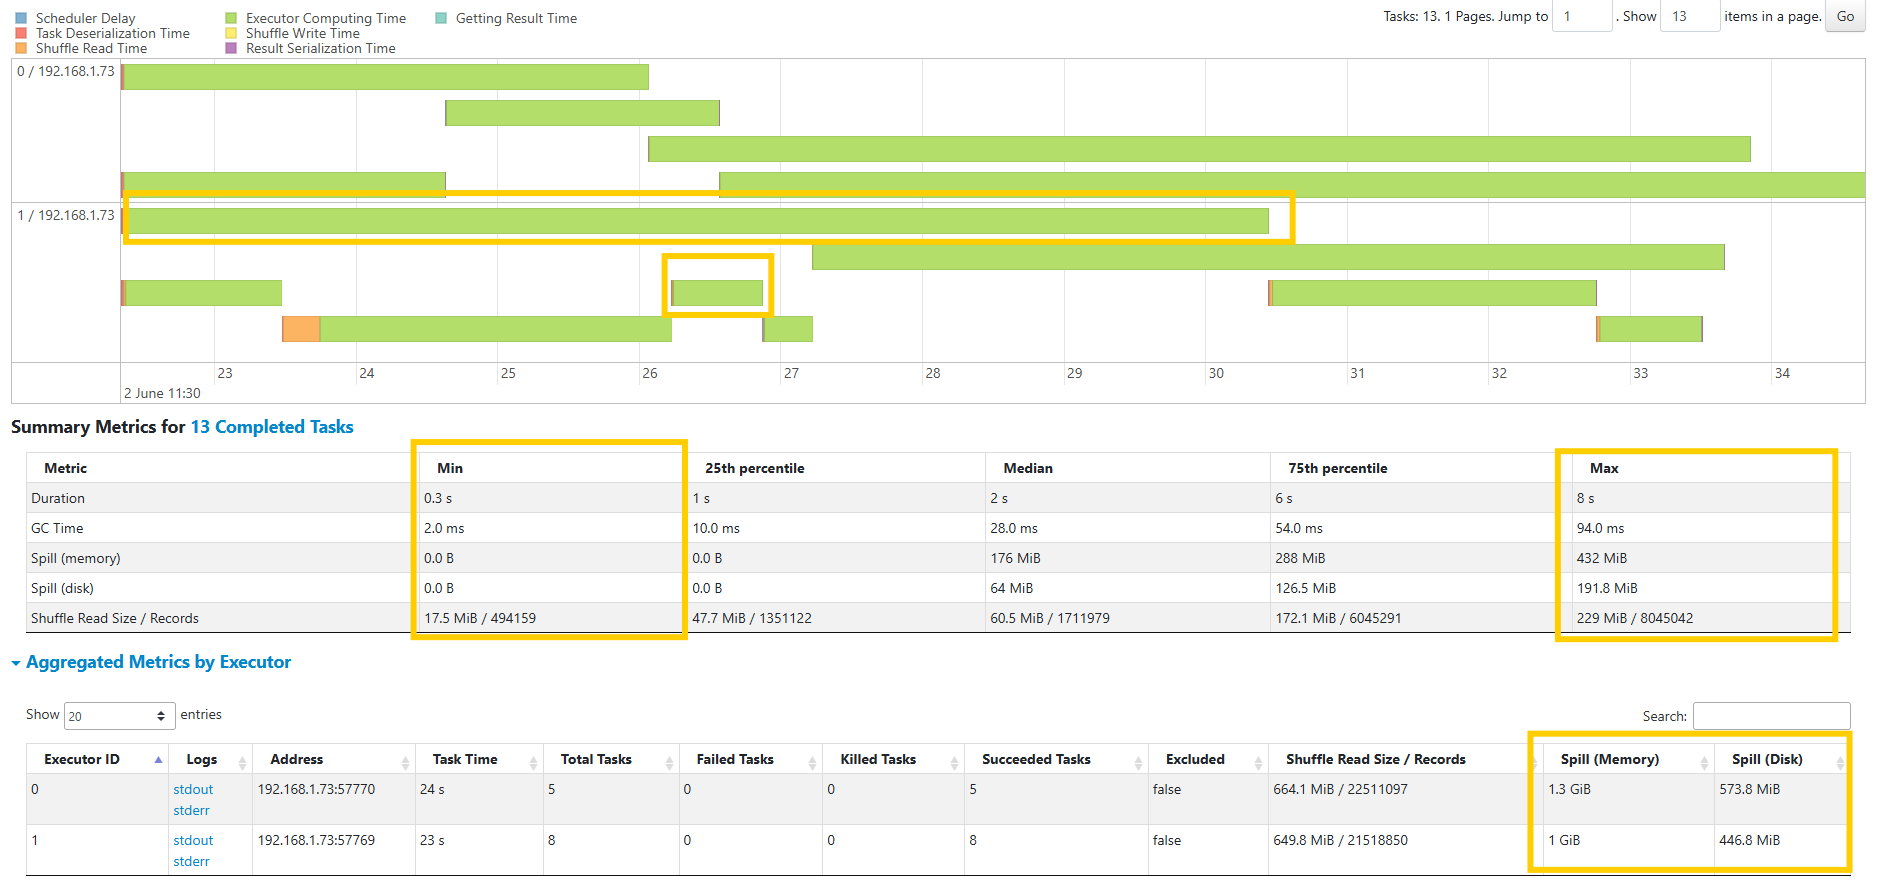

## Execution Analysis

The Spark UI shows that the join was executed successfully no one table fits in memory forcing Spark to perform a shuffle-based join strategy.

Job was completed in approximately 30 seconds but the execution metrics reveal clear signs of data skew and memory pressure.

### Key Observations

#### Task Duration Imbalance

The task duration distribution is uneven:

| Metric | Value |
|----------|----------|
| Min Duration | 0.3s |
| Median Duration | 2s |
| 75th Percentile | 6s |
| Max Duration | 8s |

Some tasks took significantly longer than others not like in the previous scenario but we need to be aware because it still happens, on a smaller scale but it's still present.

---

#### Shuffle Activity

The join generated a substantial amount of shuffle traffic:

| Metric | Value |
|----------|----------|
| Min Shuffle Read | 17 MB |
| Min Records Read | 494,159 |
| Max Shuffle Read | 229 MB |
| Max Records Read | 8,045,042 |

The large shuffle read volume confirms that Spark had to redistribute data across executors before performing the join

---

#### Memory Pressure and Spill

One of the most interesting findings is the amount of spill generated during execution.

Per task:

| Metric | Max |
|----------|----------|
| Spill (Memory) | 432 MiB |
| Spill (Disk) | 191.8 MiB |

Aggregated by executor:

| Executor | Memory Spill | Disk Spill |
|----------|----------|----------|
| Executor 0 | 1.3 GiB | 573.8 MiB |
| Executor 1 | 1.0 GiB | 446.8 MiB |

These values indicate that some tasks could not keep in the executors memory as result, spark had to spill data to disk, and make spark write and re-read data from the intermediate are like on the scenario 1.

---

### Key Notes

The job completed relatively quickly, but the execution metrics reveal that Spark was already experiencing the effects of data skew:

* Uneven task durations
* Large shuffle reads
* Significant memory spill
* Disk spill caused by memory pressure

This demonstrates an important concept in Spark performance tuning:

> A successful and fast-running job is not necessarily an efficient job.

Even though the workload finished in under a minute, spark had to spill several gigabytes of intermediate data and process highly uneven partitions
These characteristics make this workload a strong candidate for further optimization using techniques such as key salting

It is also important to note that all Adaptive Query Execution (AQE) optimizations were enabled during this experiment, including:

* Adaptive Query Execution (AQE)
* Skew Join Optimization
* Coalesce Partitions

The Spark UI shows that these optimizations were able to reduce the impact of skew by coalescing partitions and mitigating some of the imbalance between tasks.
However, because the dataset contains an extreme concentration of records in only a few `order_id` values, AQE was not able to fully eliminate the problem.

The remaining memory spill, disk spill, and task duration imbalance indicate that the workload is still affected by heavily skewed partitions. This highlights an important limitation of automatic optimizations: while AQE can significantly improve execution plans, extremely skewed keys may still require manual intervention.

The next step is try salting technique on the skewed `order_id` values can distribute the workload more evenly across partitions, further reduce spill, and improve overall resource utilization.


---

# Cenario 3 with configs enabled (AQE + Skew Join + Coalesce Partitions)

We can see that 5 `order_id` values are hot keys. These keys concentrate most of the records in the `fact_order_lines` table, which creates an uneven data distribution during the join.

To reduce this skew, we can apply a salting technique only to these hot keys.


|order_id|count   |
|--|--|
|1       |10 000 001|
|2       |8 000 001 |
|3       |7 000 000 |
|4       |6 000 000 |
|5       |4 000 000 |
|1695730 |7       |
|5046944 |7       |
|3515241 |7       |
|1955851 |7       |
|2991968 |7       |

hot_order_ids = [1, 2, 3, 4, 5]
salt_buckets = 50

Here we will have at the end something like that
|order_id|salt   | Count
|--|--|--|
|1       |1 |200 000
|1       |2 |200 000
|1       |3 |200 000
|1       |4 |200 000
|1       |.. |200 000
|1       |50 |200 000


In [ ]:
hot_order_ids = [1, 2, 3, 4, 5]
salt_buckets = 50

fact_orders_lines_salted = (
    fact_orders_lines
    .withColumn(
        "salt",
        when(
            col("order_id").isin(hot_order_ids),
            (rand(seed=42) * salt_buckets).cast("int")
        ).otherwise(F.lit(0))
    )
)

In [ ]:
salt_values = spark.range(0, salt_buckets).withColumnRenamed("id", "salt")

orders_hot_salted = (
    fact_orders
    .filter(col("order_id").isin(hot_order_ids))
    .crossJoin(salt_values)
)

orders_non_hot = (
    fact_orders
    .filter(~col("order_id").isin(hot_order_ids))
    .withColumn("salt", lit(0).cast("long"))
)

fact_orders_salted = orders_hot_salted.unionByName(orders_non_hot)

In [ ]:
import time

start_time = time.time()

spark.sparkContext.setJobDescription('Join_Deltas_Orders_OrderLines_Salted')

Df_Joined_Salted = fact_orders_lines_salted.join(fact_orders_salted, on=["order_id", "salt"], how="inner")

Df_Joined_Salted.write.format("noop").mode("overwrite").save() # Trigger the execution of the join without writing to storage

end_time = time.time()
print(f"Time of execution: {end_time - start_time} seconds")

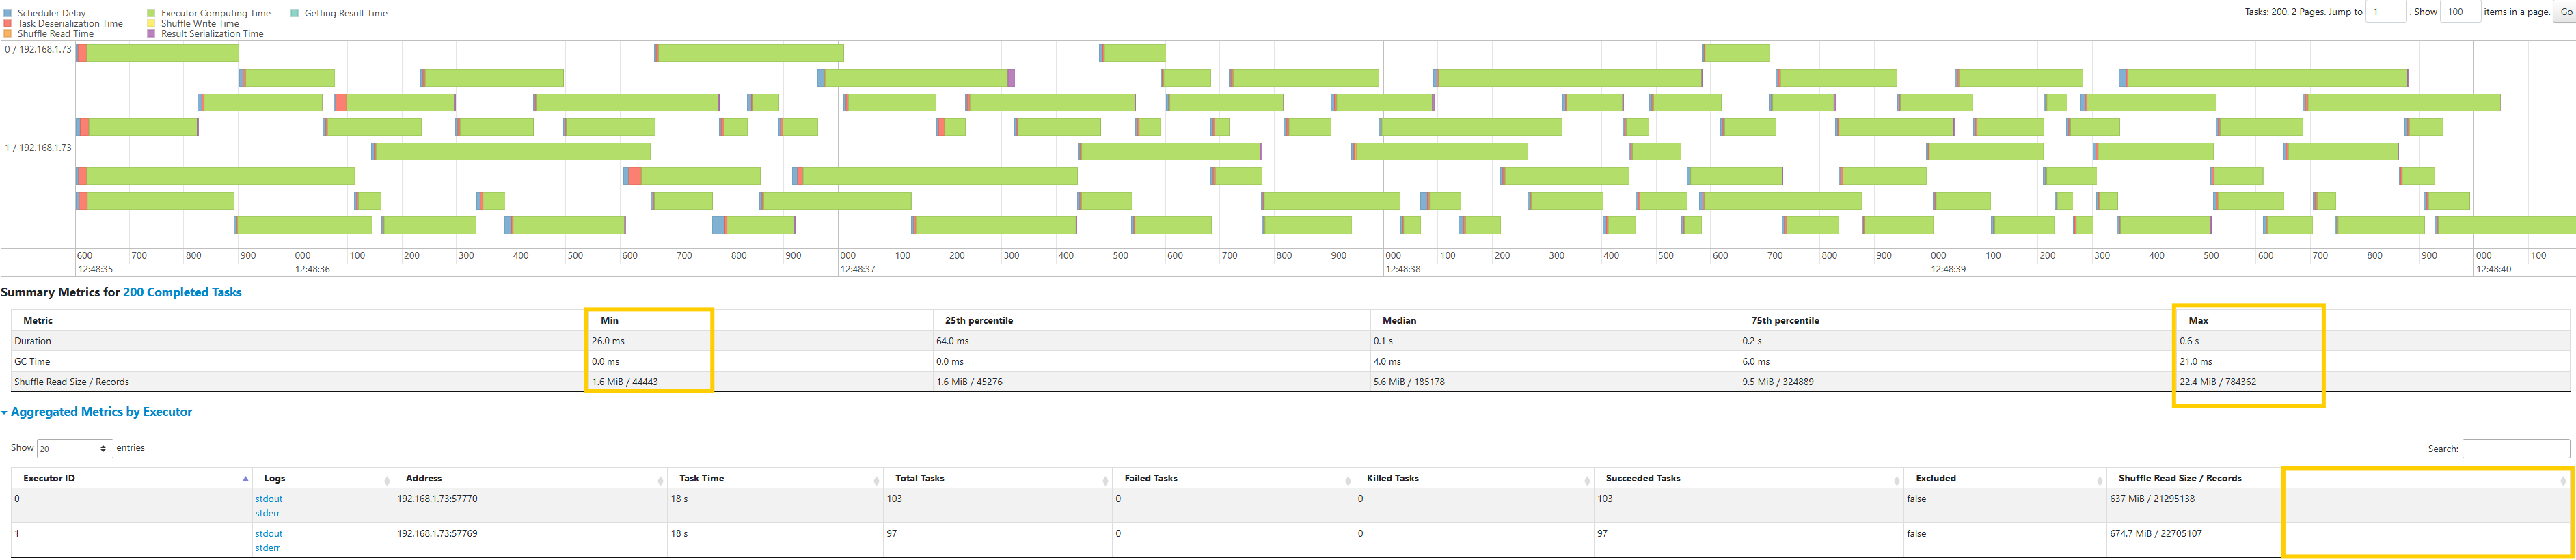

## Execution Analysis

The Spark UI shows a significant improvement in workload distribution after applying the salting technique

### Key Observations

#### Balanced Task Distribution

The execution was distributed across **200 completed tasks** but this time all tasks are more uniform, providing a much higher level of parallelism compared to the previous execution.

Task durations are now very consistent:

| Metric | Value |
|----------|----------|
| Min Duration | 26 ms |
| 25th Percentile | 64 ms |
| Median | 0.1 s |
| 75th Percentile | 0.2 s |
| Max Duration | 0.6 s |

The small difference between the minimum and maximum task duration indicates that the workload is now evenly distributed across partitions
There are no obvious long-running tasks that would suggest severe partition imbalance

---

#### No Spill Activity

One of the most important observations is there is no Data spill memory or disk

| Metric | Value |
|----------|----------|
| Spill (Memory) | 0 B |
| Spill (Disk) | 0 B |

This means that spark fits on the memory of each executor without writing and re-read from temporary location

The absence of spill is a strong indicator that partition sizes are now much more manageable and that memory pressure has been significantly reduced

---

#### Consistent Shuffle Distribution

Shuffle reads are also well balanced across tasks:

| Metric | Value |
|----------|----------|
| Min Shuffle Read | 1.6 MiB |
| Median Shuffle Read | 5.6 MiB |
| Max Shuffle Read | 22.4 MiB |

Some variation still exists, the difference between partitions is relatively small compared to what is typically observed in heavily skewed workloads

This suggests that the data is being distributed more evenly during the shuffle phase, allowing executors to process partitions at a similar rate

---

#### Executor Workload Balance

The workload is evenly shared between both executors:

| Executor | Task Time |
|----------|----------|
| Executor 0 | 18 s |
| Executor 1 | 18 s |

Additionally, the shuffle volume processed by each executor is almost identical:

| Executor | Shuffle Read |
|----------|----------|
| Executor 0 | 637 MiB |
| Executor 1 | 674 MiB |

This balanced utilization indicates that Spark was able to leverage cluster resources efficiently without creating bottlenecks on a specific executor

---

### Summary

The execution metrics show a healthy and well-balanced workload:

- High parallelism with 200 tasks
- Very small variance in task duration
- No memory spill
- No disk spill
- Even shuffle distribution
- Balanced executor utilization





---

## Scenario Comparison: AQE vs AQE + Salting

In this experiment, we compared three different execution scenarios for a large-to-large join with extreme `order_id` skew

The dataset contains five hot keys responsible for more than 90% of the records in the `fact_order_lines` table

---

## Scenario 1 — AQE Disabled, No Salting

In the first scenario, all adaptive Spark optimizations were disabled

* AQE: Disabled
* Skew Join Optimization: Disabled
* Coalesce Partitions: Disabled
* Salting: Disabled

Spark created 200 tasks, but the workload was highly unbalanced

Most tasks finished very quickly, while a small number of tasks took significantly longer. The maximum task duration reached 10 seconds, while the median duration was only 33 ms

This indicates severe partition imbalance caused by skewed join keys

The shuffle read distribution also confirms the issue:

| Metric | Value |
|----------|----------|
| Min Shuffle Read | 1.6 MiB |
| Median Shuffle Read | 1.6 MiB |
| Max Shuffle Read | 285.9 MiB |


The job also generated memory and disk spill:

| Executor | Memory Spill | Disk Spill |
|----------|----------|----------|
| Executor 0 | 880 MiB | 392.8 MiB |
| Executor 1 | 1026 MiB | 445.7 MiB |

This scenario clearly shows the raw impact of data skew

---

## Scenario 2 — AQE Enabled, No Salting

In the second scenario, Spark adaptive optimizations were enabled.

* AQE: Enabled
* Skew Join Optimization: Enabled
* Coalesce Partitions: Enabled
* Salting: Disabled

Spark reduced the number of tasks from 200 to 13.

This shows that AQE and coalesce partitions were active and Spark tried to optimize the execution plan at runtime

The task duration distribution improved slightly:

| Metric | Value |
|----------|----------|
| Min Shuffle Read | 17 MB |
| Min Records Read | 494,159 |
| Max Shuffle Read | 229 MB |
| Max Records Read | 8,045,042 |

However, the execution still showed signs of skew. Some tasks were still much longer than others, and spill was still present

| Executor   | Memory Spill | Disk Spill |
| ---------- | -----------: | ---------: |
| Executor 0 |      1.3 GiB |  573.8 MiB |
| Executor 1 |      1.0 GiB |  446.8 MiB |

This is an important observation: AQE helped reduce the number of partitions and partially mitigated the skew, but it did not fully solve the problem

Because the skew was extreme, with five keys concentrating most of the data, Spark's automatic optimizations were not enough to eliminate memory pressure and spill

---

## Scenario 3 — AQE Enabled with Salting

In the third scenario, we kept Spark adaptive optimizations enabled and applied salting to the five hot `order_id` values

* AQE: Enabled
* Skew Join Optimization: Enabled
* Coalesce Partitions: Enabled
* Salting: Enabled

This produced a much healthier execution profile

Spark executed 200 tasks with a much more balanced distribution

| Metric          | Value |
| --------------- | ----: |
| Min Duration    | 26 ms |
| Median Duration | 0.1 s |
| Max Duration    | 0.6 s |

The maximum task duration dropped significantly compared to the previous scenarios

The shuffle read distribution also became much more balanced:

| Metric              |    Value |
| ------------------- | -------: |
| Median Shuffle Read |  5.6 MiB |
| Max Shuffle Read    | 22.4 MiB |

Most importantly, spill was eliminated:

| Metric       | Value |
| ------------ | ----: |
| Memory Spill |   0 B |
| Disk Spill   |   0 B |

By salting the hot keys, each skewed `order_id` was split into 50 smaller buckets. Instead of processing millions of records under a single join key, Spark processed smaller combinations such as:

```text
(order_id = 1, salt = 0)
(order_id = 1, salt = 1)
(order_id = 1, salt = 2)
...
(order_id = 1, salt = 49)
```

This allowed Spark to distribute the workload more evenly across partitions.

---

## Final Comparison

| Metric            | Scenario 1: AQE OFF, No Salting | Scenario 2: AQE ON, No Salting | Scenario 3: AQE ON + Salting |
| ----------------- | ------------------------------: | -----------------------------: | ---------------------------: |
| Tasks             |                             200 |                             13 |                          200 |
| Max Task Duration |                            10 s |                            8 s |                        0.6 s |
| Max Shuffle Read  |                       285.9 MiB |                        229 MiB |                     22.4 MiB |
| Memory Spill      |                             Yes |                            Yes |                           No |
| Disk Spill        |                             Yes |                            Yes |                           No |
| Workload Balance  |                            Poor |             Partially improved |                    Very good |

---

## Key Takeaway

AQE, Skew Join Optimization, and Coalesce Partitions can help Spark adapt execution plans at runtime, but they are not always enough when the skew is extreme

In this case, five `order_id` values represented more than 90% of the dataset. AQE reduced the number of tasks and partially improved execution, but the workload still generated significant memory and disk spill

Manual salting provided the best result because it directly addressed the root cause: the concentration of records in a few join keys

By splitting the hot keys into multiple salted keys, Spark was able to distribute the workload more evenly, eliminate spill, and significantly reduce task duration imbalance
